# Medical Sound Classification -> LSTM, Bidirectioneel LSTM en 1D CNN

In [27]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import scipy.signal
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, Model

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix

## 1. Data laden

Voor we kunnen beginnen moeten we natuurlijk de data laden, hier mogen we zeker niet vergeten de preprocessing stappen van het vorige notebook.

In [ ]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

df_train = df_train.drop(df_train[df_train['candidateID'] == '5ee582f2832c2'].index)

df_train['coldPresent_missing'] = df_train['coldPresent'].isna().astype(int)
df_train['coldPresent'] = df_train['coldPresent'].fillna(0)

print(f"train samples: {len(df_train)}")
print(df_train['disease'].value_counts())

Train samples: 545
disease
1    238
2    167
0    140
Name: count, dtype: int64


## 2. YAMNet laden

In [29]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("YAMNet geladen.")

YAMNet geladen.


## 3. Embedding extractie

Hier zullen we het een klein beetje anders doen, hier zullen we namelijk onze embeddings niet aggregaten omdat we voor LSTM juist de informatie doorheen de tijd nodig hebben. Moesten we dit toch doen zouden we belangrijke informatie verliezen.

In [30]:
def extract_embeddings_sequence(waveform):
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return embeddings.numpy()

## 4. Dataset bouwen

We bouwen twee datasets:
- `X_audio`: tijdreeks embeddings -> voor LSTM
- `X_meta`: metadata features -> apart gecombineerd

We zullen hier dus de verschillende segmenten gebruiken om zo meer data te gebruiken. Ieder segment krijgt ook steeds de metadata mee.

Cough segmenten + vowel (indien voldoende tijd)

TODO vowels

In [31]:
META_COLS = ['age', 'gender', 'tbContactHistory', 'wheezingHistory',
             'phlegmCough', 'familyAsthmaHistory', 'feverHistory',
             'coldPresent', 'packYears', 'coldPresent_missing']

df_filled = df_train.fillna(0)

X_audio  = []  # tijdreeks embeddings    
X_meta = []  # metadata
y_list = []  # labels

skipped = 0

for _, row in df_filled.iterrows():
    cid     = row['candidateID']
    disease = row['disease']
    meta    = row[META_COLS].values.astype(np.float32)
    
    # --- Cough segmenten ---
    seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
    if os.path.exists(seg_folder):
        for fname in os.listdir(seg_folder):
            if fname.endswith("_processed.wav"):
                fp = os.path.join(seg_folder, fname)
                try:
                    waveform, sr = librosa.load(fp, sr=16000)
                    emb_seq = extract_embeddings_sequence(waveform)
                    X_audio.append(emb_seq)
                    X_meta.append(meta)
                    y_list.append(disease)
                except Exception as e:
                    print(f"Fout bij {fp}: {e}")
                    skipped += 1
    
    # # --- Vowel ---
    # vowel_path = os.path.join("data/sounds/sounds", cid, "vowel_processed.wav")
    # if os.path.isfile(vowel_path):
    #     try:
    #         waveform, sr = librosa.load(vowel_path, sr=16000)
    #         emb_seq = extract_embeddings_sequence(waveform)
    #         X_audio.append(emb_seq)
    #         X_meta.append(meta)
    #         y_list.append(disease)
    #     except Exception as e:
    #         print(f"Fout bij {vowel_path}: {e}")
    #         skipped += 1

X_audio  = np.array(X_audio,  dtype=np.float32)   # (samples, MAX_FRAMES, 1024)
X_meta = np.array(X_meta, dtype=np.float32)   # (samples, n_meta)
y_arr  = np.array(y_list)

print(f"X_audio shape : {X_audio.shape}")
print(f"X_meta shape: {X_meta.shape}")
print(f"Labels shape: {y_arr.shape}")
print(f"Overgeslagen : {skipped}")

X_audio shape : (8317, 4, 1024)
X_meta shape: (8317, 10)
Labels shape: (8317,)
Overgeslagen : 0


In [ ]:
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)


le = LabelEncoder()
y_encoded = le.fit_transform(y_arr)
num_classes = len(le.classes_)
print(f"Klassen: {le.classes_}  ({num_classes} klassen)")

# Hier splitsen we de data maar houden we onze x_audio en x_meta apart, zodat we ze later als aparte inputs kunnen gebruiken in het model.
split = train_test_split(
    X_audio,
    X_meta_scaled,
    y_encoded,
    test_size=0.2,
    random_state=1234,
    stratify=y_encoded
)

X_audio_train, X_audio_val, X_meta_train, X_meta_val, y_train, y_val = split

y_train_onehot = to_categorical(y_train, num_classes)
y_val_onehot   = to_categorical(y_val,   num_classes)

print(f"Training  : {len(X_audio_train)} samples")
print(f"Validatie : {len(X_audio_val)} samples")

Klassen: [0 1 2]  (3 klassen)
Training  : 6653 samples
Validatie : 1664 samples


## 5. Modellen

We bouwen drie varianten en vergelijken ze:

| Model | Beschrijving |
|-------|--------------|
| **LSTM** | Unidirectionele LSTM over tijdreeks + metadata |
| **BiLSTM** | Bidirectionele LSTM (kijkt ook achteruit) + metadata |
| **1D CNN** | Convoluties over de tijdas (sneller, stabiel bij kleine data) + metadata |

Om de modellen te maken zullen we iets gebruiken dat late fusion noemt. We trainen eerst onze audio en metadata tak apart om ze daarna samen te voegen.

### 5.1 LSTM

We zullen beginnen met een standaard LSTM model.

In [ ]:
def fit_model_LSTM(window_size_audio=4, window_size_meta=10):
    # audio tak
    audio_input = layers.Input(shape=(window_size_audio, 1024)) #onze audio files zijn steeds 4 frames van 1024 features (YAMNet embeddings)
    
    audio_features = layers.LSTM(128, return_sequences=True)(audio_input) #TODO pruts een keer met activation of niet want standaard werkt
    audio_features = layers.Dropout(0.3)(audio_features) 
    audio_features = layers.LSTM(64)(audio_features)
    audio_features = layers.Dropout(0.3)(audio_features)
    
    # metadata tak
    meta_input = layers.Input(shape=(window_size_meta,)) # Er zijn 10 metadata features
    
    meta_features = layers.Dense(32, activation='relu')(meta_input)
    meta_features = layers.Dropout(0.2)(meta_features)
    
    # beide takken combineren
    combined = layers.concatenate([audio_features, meta_features])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(3, activation='softmax')(out) # We hebben 3 mogelijke resultaten.
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer="adam", 
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # training
    early_stop = EarlyStopping(
        monitor='val_loss', #TODO check een keer of dit nodig is?
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_audio_train, X_meta_train], y_train_onehot,
        validation_data=([X_audio_val, X_meta_val], y_val_onehot),
        epochs= 60,
        batch_size= 16,
        callbacks=[early_stop],
        verbose=1
    )

    val_loss, val_acc = model.evaluate([X_audio_val, X_meta_val], y_val_onehot, verbose=0) #val accuracy houden we bij voor later te vergelijken. #TODO verbose?
    y_pred = np.argmax(model.predict([X_audio_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"-LSTM - Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return model, history, val_acc, macro_f1, y_pred

In [34]:
lstm_model, hist_lstm, acc_lstm, f1_lstm, pred_lstm = fit_model_LSTM() 

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7340 - loss: 0.6420 - val_accuracy: 0.8275 - val_loss: 0.4501
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8094 - loss: 0.4839 - val_accuracy: 0.8444 - val_loss: 0.4049
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8291 - loss: 0.4447 - val_accuracy: 0.8498 - val_loss: 0.3662
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8338 - loss: 0.4214 - val_accuracy: 0.8654 - val_loss: 0.3633
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8440 - loss: 0.4020 - val_accuracy: 0.8654 - val_loss: 0.3442
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8536 - loss: 0.3845 - val_accuracy: 0.8744 - val_loss: 0.3303
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8547 - loss: 0.3694 - val_accuracy: 0.8852 - val_loss: 0.3128
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8581 - loss: 0.3575 - val_accuracy: 0.

### 5.2 Bidirectional LSTM

Nu zullen we een bidirectionaal model proberen.

In [ ]:
def fit_model_BiLSTM(window_size_audio=4, window_size_meta=10): 
    # audio tak
    audio_input = layers.Input(shape=(window_size_audio, 1024))
    
    audio_features = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(audio_input)
    audio_features = layers.Dropout(0.3)(audio_features)
    audio_features = layers.Bidirectional(layers.LSTM(64))(audio_features)
    audio_features = layers.Dropout(0.3)(audio_features)
    
    # metadata tak
    meta_input = layers.Input(shape=(window_size_meta,)) 
    meta_features = layers.Dense(32, activation='relu')(meta_input)
    meta_features = layers.Dropout(0.2)(meta_features)
    
    # beide takken combineren
    combined = layers.concatenate([audio_features, meta_features])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(3, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer="adam", 
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


    # training
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_audio_train, X_meta_train], y_train_onehot,
        validation_data=([X_audio_val, X_meta_val], y_val_onehot),
        epochs= 60,
        batch_size= 16,
        callbacks=[early_stop],
        verbose=1
    )

    val_loss, val_acc = model.evaluate([X_audio_val, X_meta_val], y_val_onehot, verbose=0)
    y_pred = np.argmax(model.predict([X_audio_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"-BiLSTM - Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return model, history, val_acc, macro_f1, y_pred

In [36]:
bilstm_model, hist_bilstm, acc_bilstm, f1_bilstm, pred_bilstm = fit_model_BiLSTM()

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7300 - loss: 0.6537 - val_accuracy: 0.8233 - val_loss: 0.4527
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8106 - loss: 0.4922 - val_accuracy: 0.8407 - val_loss: 0.4046
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8252 - loss: 0.4480 - val_accuracy: 0.8419 - val_loss: 0.3839
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8312 - loss: 0.4244 - val_accuracy: 0.8558 - val_loss: 0.3505
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8401 - loss: 0.4017 - val_accuracy: 0.8708 - val_loss: 0.3513
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8444 - loss: 0.3914 - val_accuracy: 0.8744 - val_loss: 0.3296
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8544 - loss: 0.3679 - val_accuracy: 0.8690 - val_loss: 0.3130
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8613 - loss: 0.3508 - val_accuracy: 0

### 5.3 1D CNN

Omdat we niet zo veel data hebben is het een keer interessant om een 1D CNN model te proberen.

In [ ]:
def fit_model_1DCNN(window_size_audio=4, window_size_meta=10):
    # Audio tak 
    audio_input = layers.Input(shape=(window_size_audio, 1024))
    
    audio_features = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(audio_input)
    audio_features = layers.BatchNormalization()(audio_features)
    audio_features = layers.MaxPooling1D(pool_size=2)(audio_features)
    audio_features = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(audio_features)
    audio_features = layers.BatchNormalization()(audio_features)
    audio_features = layers.GlobalAveragePooling1D()(audio_features)
    audio_features = layers.Dropout(0.4)(audio_features)
    
    # Metadata tak 
    meta_input = layers.Input(shape=(window_size_meta,))
    meta_features = layers.Dense(32, activation='relu')(meta_input)
    meta_features = layers.Dropout(0.2)(meta_features)
    
    # Combineer 
    combined = layers.concatenate([audio_features, meta_features])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(3, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer="adam",
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # training
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_audio_train, X_meta_train], y_train_onehot,
        validation_data=([X_audio_val, X_meta_val], y_val_onehot),
        epochs= 70,
        batch_size= 16,
        callbacks=[early_stop],
        verbose=1
    )

    val_loss, val_acc = model.evaluate([X_audio_val, X_meta_val], y_val_onehot, verbose=0)
    y_pred = np.argmax(model.predict([X_audio_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"-1DCNN - Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return model, history, val_acc, macro_f1, y_pred

In [38]:
cnn_model, hist_cnn, acc_cnn, f1_cnn, pred_cnn = fit_model_1DCNN() 

Epoch 1/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7170 - loss: 0.6726 - val_accuracy: 0.8215 - val_loss: 0.4718
Epoch 2/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8067 - loss: 0.4953 - val_accuracy: 0.8407 - val_loss: 0.4225
Epoch 3/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8168 - loss: 0.4676 - val_accuracy: 0.8642 - val_loss: 0.3756
Epoch 4/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8309 - loss: 0.4361 - val_accuracy: 0.8672 - val_loss: 0.3622
Epoch 5/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8372 - loss: 0.4193 - val_accuracy: 0.8714 - val_loss: 0.3538
Epoch 6/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8440 - loss: 0.4003 - val_accuracy: 0.8786 - val_loss: 0.3412
Epoch 7/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8470 - loss: 0.3901 - val_accuracy: 0.8822 - val_loss: 0.3280
Epoch 8/70
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8595 - loss: 0.3753 - val_accuracy: 0.

## 6. Vergelijking

Nu zullen we onze drie modellen een keer vergelijken om te zien welke de beste is.

 Model  Val Accuracy  Macro F1
  LSTM      0.890625  0.885164
BiLSTM      0.891827  0.886113
1D CNN      0.903245  0.897484


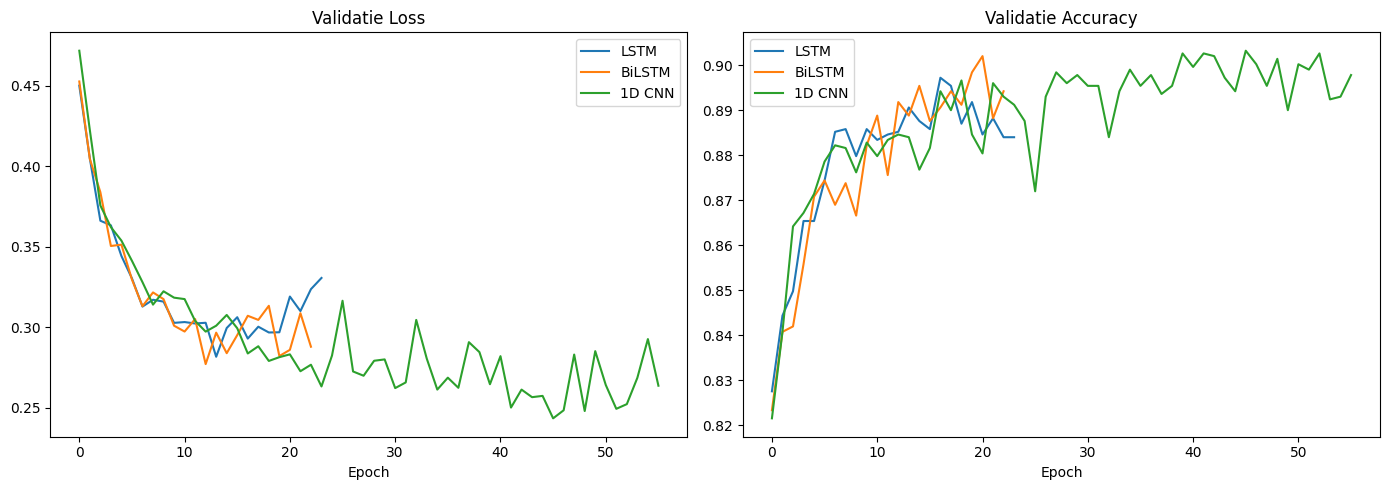

In [39]:
results = pd.DataFrame({
    'Model'      : ['LSTM', 'BiLSTM', '1D CNN'],
    'Val Accuracy': [acc_lstm, acc_bilstm, acc_cnn],
    'Macro F1'   : [f1_lstm,  f1_bilstm,  f1_cnn]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name in [(hist_lstm, 'LSTM'), (hist_bilstm, 'BiLSTM'), (hist_cnn, '1D CNN')]:
    axes[0].plot(hist.history['val_loss'], label=name)
    axes[1].plot(hist.history['val_accuracy'], label=name)

axes[0].set_title('Validatie Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validatie Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

Nu gebruiken we de voorspellingen van daarnet om een confusion matrix te zien.

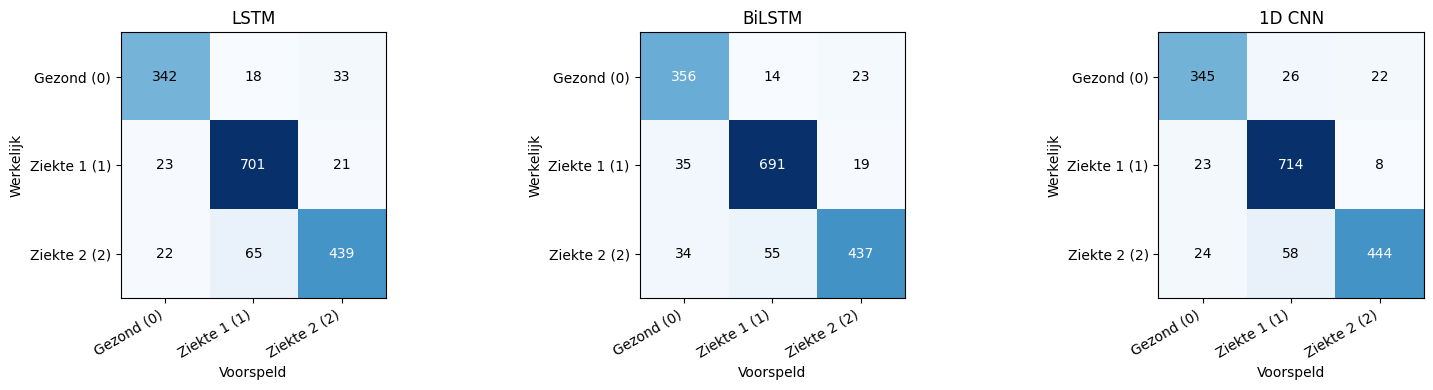

In [40]:
# Confusion matrices naast elkaar
class_names = ['Gezond (0)', 'Ziekte 1 (1)', 'Ziekte 2 (2)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, preds, name in [
    (axes[0], pred_lstm,   'LSTM'),
    (axes[1], pred_bilstm, 'BiLSTM'),
    (axes[2], pred_cnn,    '1D CNN')
]:
    cm = confusion_matrix(y_val, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=30, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Voorspeld')
    ax.set_ylabel('Werkelijk')
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 7. Beste model opslaan

TODO

In [41]:
# import joblib

best_f1 = max(f1_lstm, f1_bilstm, f1_cnn)
best_name = ['LSTM', 'BiLSTM', '1D CNN'][[f1_lstm, f1_bilstm, f1_cnn].index(best_f1)]
best_model = {'LSTM': lstm_model, 'BiLSTM': bilstm_model, '1D CNN': cnn_model}[best_name]

print(f"Beste model: {best_name} (Macro F1 = {best_f1:.4f})")

# best_model.save(f"best_model_{best_name.replace(' ', '_').lower()}.keras")
# joblib.dump(scaler, "scaler_lstm_experiment.pkl")
# joblib.dump(le,     "label_encoder_lstm_experiment.pkl")

# print("Model, scaler en label encoder opgeslagen.")

Beste model: 1D CNN (Macro F1 = 0.8975)


## 8. model testen op testset

Nu zullen we ons model eens testen en een keer kijken naar de bovenste files om te zien of alles werkt.

In [42]:
# df_test_filled = df_test.fillna(0)
# if 'coldPresent_missing' not in df_test_filled.columns:
#     df_test_filled['coldPresent_missing'] = df_test['coldPresent'].isna().astype(int)

# X_audio_test  = []
# X_meta_test = []
# test_ids    = []

# for _, row in df_test_filled.iterrows():
#     cid  = row['candidateID']
#     meta = row[META_COLS].values.astype(np.float32)

#     seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
#     if os.path.exists(seg_folder):
#         for fname in os.listdir(seg_folder):
#             if fname.endswith("_processed.wav"):
#                 fp = os.path.join(seg_folder, fname)
#                 waveform, _ = librosa.load(fp, sr=16000)
#                 emb_seq = extract_embeddings_sequence(waveform)
#                 X_audio_test.append(emb_seq)
#                 X_meta_test.append(meta)
#                 test_ids.append(cid)

# X_audio_test  = np.array(X_audio_test,  dtype=np.float32)
# X_meta_test = scaler.transform(np.array(X_meta_test, dtype=np.float32))

# y_pred_test = np.argmax(best_model.predict([X_audio_test, X_meta_test]), axis=1)
# y_pred_labels = le.inverse_transform(y_pred_test)

# submission = pd.DataFrame({'candidateID': test_ids, 'disease': y_pred_labels})
#  # Aggregeer per kandidaat (meerdere segmenten -> majority vote)
# submission = submission.groupby('candidateID')['disease'].agg(lambda x: x.mode()[0]).reset_index()
# #submission.to_csv('submission.csv', index=False)
# print(submission.head())